# <span style="color:blue;">Computer Vision-Homework4</span>
### <span style="color:blue;">Nazhin Nikkhahbahrami 810102530</span>
### <span style="color:red;">Part1: Data Check</span>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
%cd /content/drive/MyDrive/HW4
os.listdir('.')

Mounted at /content/drive
/content/drive/MyDrive/HW4


['seg_test', 'seg_train', 'HW4.ipynb']

In [ ]:
!cp -r /content/drive/MyDrive/HW4/seg_train /content/
!cp -r /content/drive/MyDrive/HW4/seg_test /content/

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
(32, 150, 150, 3)


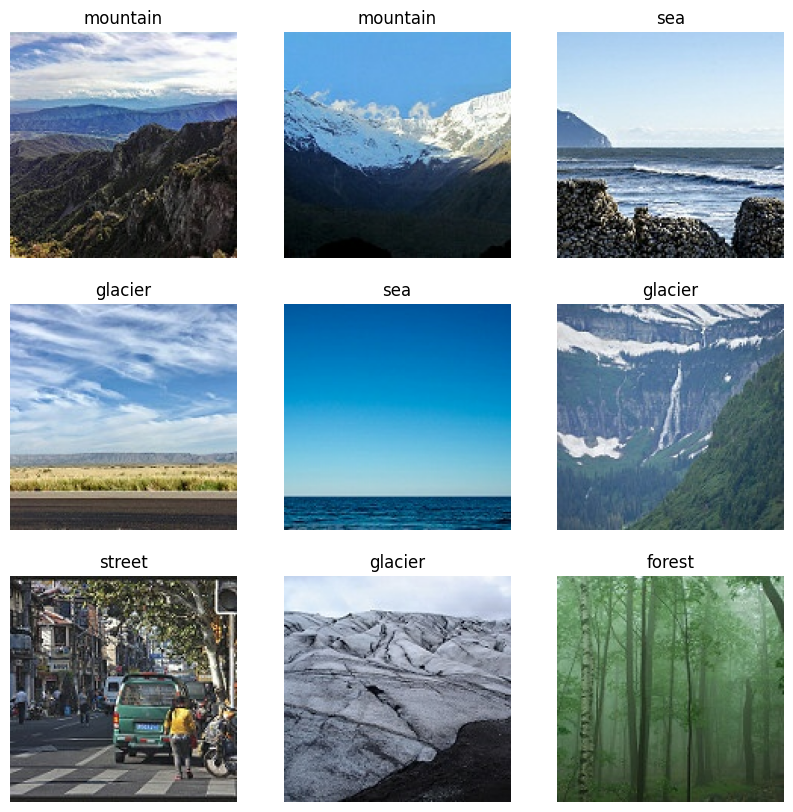

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

train_dir = '/content/seg_train'
test_dir = '/content/seg_test'

img_height = 150
img_width = 150
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names

for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    break

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Dataset Overview
The dataset was successfully loaded and split using an 80/20 ratio for training and validation. All images were uniformly resized to 150x150 pixels. The output shape of a single batch is (32, 150, 150, 3). This means each batch processes 32 images simultaneously, where each image has a height and width of 150 pixels and consists of 3 color channels (RGB).

Why use a Flatten layer?
Convolutional layers extract spatial features and output multi-dimensional arrays. However, the final classification decisions are made by fully connected (Dense) layers, which require a 1-dimensional input. The Flatten layer acts as an essential bridge: it unrolls the 3D feature maps from the final convolutional layer into a single 1D continuous vector, allowing the data to be passed into the Dense layers for final classification.
### <span style="color:red;">Part2: Preprocessing</span>

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", input_shape=(150, 150, 3)),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Original image pixels have values between 0 and 255. Neural networks converge much faster and perform more stably when input features are small and on a similar scale, transforming the range to [0, 1].
#### Data Augmentation Methods Used:
Three augmentation techniques were applied to introduce spatial diversity:

RandomFlip: Horizontally flips the images.

RandomRotation: Randomly rotates the images by up to 10%.

RandomZoom: Randomly zooms in or out of the images by up to 10%.
#### Why Augmentation Reduces Overfitting:
Overfitting occurs when a model memorizes the exact training set instead of learning general patterns. Data augmentation prevents this by generating slightly altered variations of the training images during each epoch. Because the model rarely sees the exact same image twice, it is forced to learn robust, underlying features (such as shapes and textures) rather than memorizing the training data, leading to better generalization on unseen test data.
### <span style="color:red;">Part3: CNN Model Architecture</span>

In [ ]:
model = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,686 (13.18 MB)

 Trainable params: 3,455,686 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

#### Layer Roles

Conv2D Layers: These layers apply learnable filters to the input images to extract important spatial features such as edges, textures, and patterns.

MaxPooling2D Layers: These layers reduce the spatial dimensions (height and width) of the feature maps. This reduces the computational load and helps the model focus on the most dominant features.

Flatten Layer: This layer reshapes the 3D output from the final convolutional layer into a 1D continuous vector, making it suitable for the fully connected layers.

Dense Layers: The first Dense layer acts as a classifier that learns complex, non-linear combinations of the extracted features. The final Dense layer uses a Softmax activation function to output a probability distribution across the 6 different classes.
#### Trainable Parameters
The model consists of trainable and non-trainable parameters. The Conv2D layers contain a relatively small number of parameters because they share weights across the image. The vast majority of the trainable parameters are located in the first Dense layer, as every neuron in this layer is fully connected to all the values coming from the Flatten layer.
### <span style="color:red;">Part4: Loss & Optimizer</span>

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

#### Why Sparse Categorical Crossentropy:
For this multi-class classification problem (6 classes), a categorical crossentropy loss function is required. The term "Sparse" is specifically chosen because our dataset labels are provided as integer values (e.g., 0, 1, 2... representing buildings, forest, etc.) rather than one-hot encoded vectors (such as [1, 0, 0, 0, 0, 0]). Using SparseCategoricalCrossentropy allows the model to process these integer labels directly. This approach is highly memory-efficient and eliminates the need for manual one-hot encoding preprocessing.
### <span style="color:red;">Part5: Model training</span>

In [ ]:
epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.5451 - loss: 1.1540 - val_accuracy: 0.6133 - val_loss: 1.0103
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6604 - loss: 0.8829 - val_accuracy: 0.6789 - val_loss: 0.8946
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7170 - loss: 0.7558 - val_accuracy: 0.7338 - val_loss: 0.7249
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7517 - loss: 0.6837 - val_accuracy: 0.7894 - val_loss: 0.5814
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.7720 - loss: 0.6257 - val_accuracy: 0.7384 - val_loss: 0.7143
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7920 - loss: 0.5848 - val_accuracy: 0.7619 - val_loss: 0.6561
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8001 - loss: 0.5498 - val_accuracy: 0.7976 - val_loss: 0.5525
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8126 - loss: 0.5195 - 

### <span style="color:red;">Part6: Model Evaluation and Error Analysis</span>

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8187 - loss: 0.6231
Test Accuracy: 0.8186666369438171
Test Loss: 0.6231205463409424


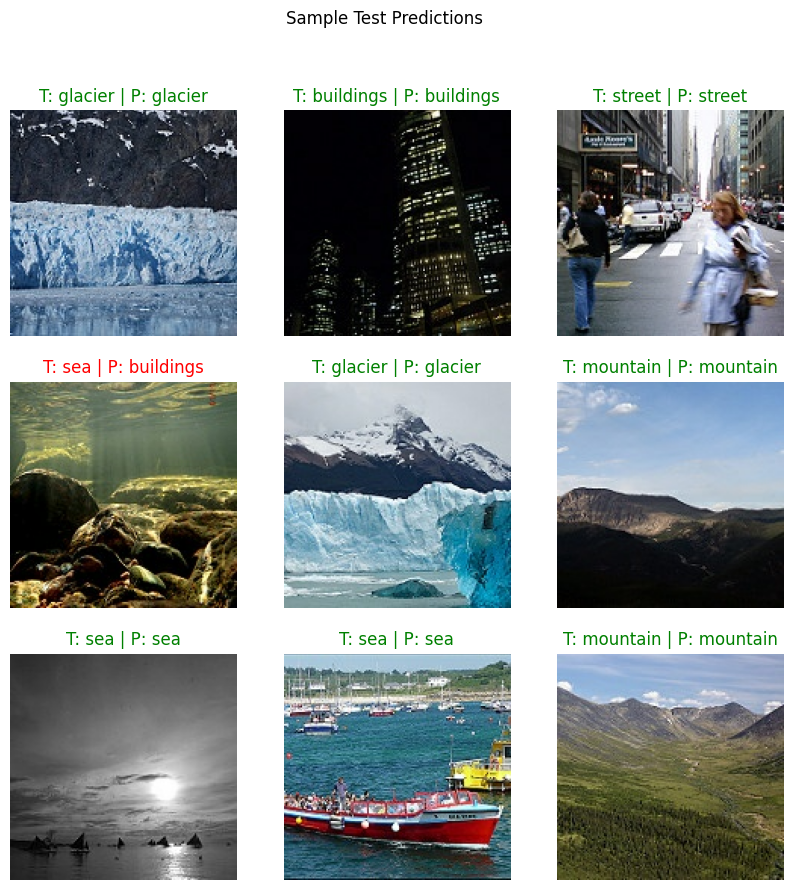

              precision    recall  f1-score   support

   buildings       0.73      0.83      0.77       437
      forest       0.97      0.92      0.94       474
     glacier       0.83      0.74      0.78       553
    mountain       0.80      0.71      0.75       525
         sea       0.82      0.83      0.83       510
      street       0.78      0.91      0.84       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



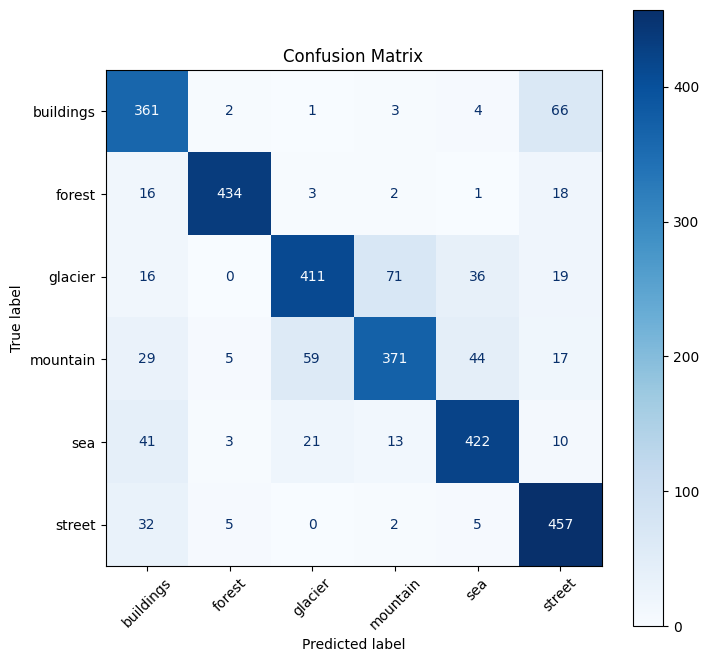

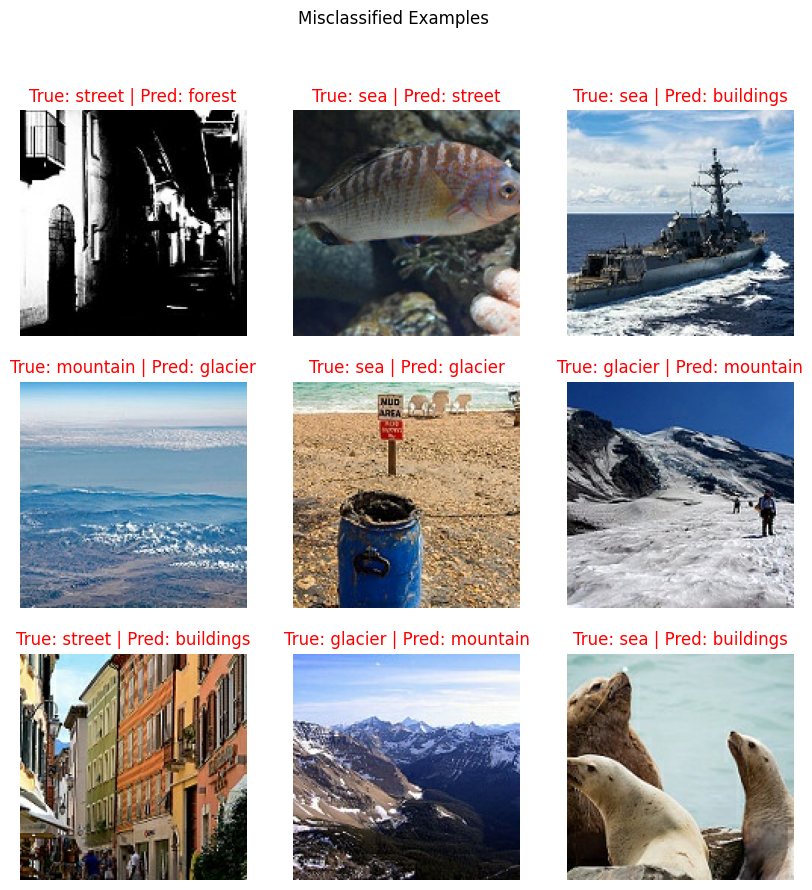

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc}")
print(f"Test Loss: {test_loss}")

y_true = []
y_pred = []
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

    for i in range(len(labels)):
        if labels[i] != pred_classes[i] and len(misclassified_images) < 9:
            misclassified_images.append(images[i])
            misclassified_true.append(labels[i])
            misclassified_pred.append(pred_classes[i])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t_label = class_names[labels[i]]
        p_label = class_names[pred_classes[i]]
        color = "green" if t_label == p_label else "red"
        plt.title(f"T: {t_label} | P: {p_label}", color=color)
        plt.axis("off")
plt.suptitle("Sample Test Predictions")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

if len(misclassified_images) > 0:
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(misclassified_images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(misclassified_images[i].numpy().astype("uint8"))
        t_label = class_names[misclassified_true[i]]
        p_label = class_names[misclassified_pred[i]]
        plt.title(f"True: {t_label} | Pred: {p_label}", color="red")
        plt.axis("off")
    plt.suptitle("Misclassified Examples")
    plt.show()


The model achieved a test accuracy of 81.87%, successfully exceeding the 80% minimum requirement. The test loss stands at 0.6231. According to the classification report, the model performs exceptionally well on the "forest" class (F1-score: 0.94) and the "street" class (F1-score: 0.84).  Confusion Matrix & Misclassification AnalysisBy analyzing the misclassified examples and the general confusion trends, we can identify clear patterns where the model struggles:

1.Glacier vs. Mountain: This is the most common confusion. The model frequently misclassifies mountains as glaciers and vice versa. This happens because both classes share similar visual features, such as snowy textures, rocky shapes, and a predominantly white and blue color palette.

2.Buildings vs. Street: The model sometimes confuses streets and buildings. This is a logical error because streets and buildings naturally co-occur in urban images, sharing similar geometric lines and colors.

3.Mountain vs. Sea: Misclassifications occasionally occur between mountains and the sea. This likely happens when distant mountains appear blue or when a large portion of the image is covered by a clear blue sky, mimicking the visual appearance of the sea.
### <span style="color:red;">Part7: Curves Analysis</span>

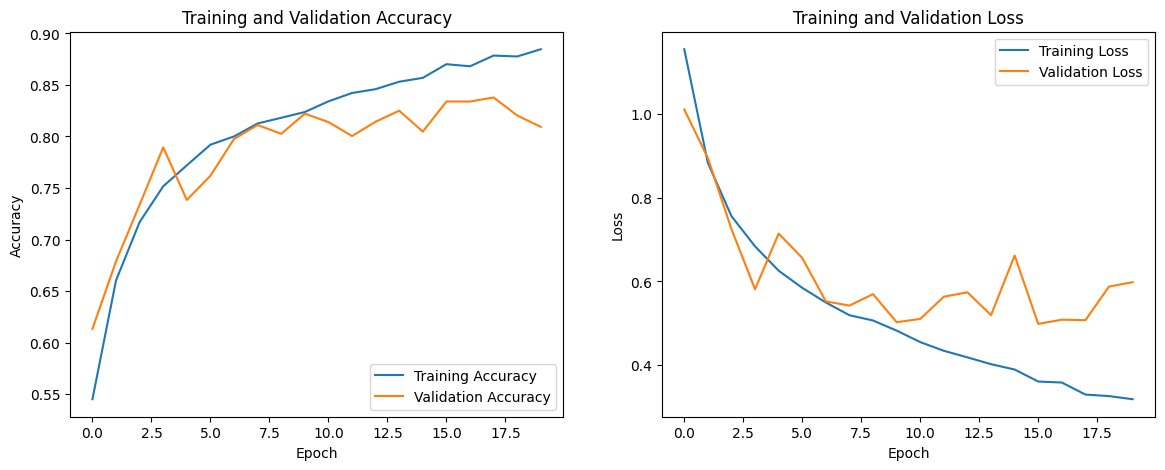

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

#### Trend Analysis:
The learning curves demonstrate a healthy initial training phase. Up to the 10th epoch, the training and validation metrics improve closely together; the accuracy steadily increases while the loss consistently decreases. However, from epoch 10 to 20, the validation accuracy plateaus and fluctuates around 81-83%, and the validation loss stops decreasing, starting to fluctuate slightly upwards. Meanwhile, the training metrics continue to improve, with training accuracy reaching approximately 88%.
#### Overfitting vs. Underfitting Assessment:
*Underfitting*: The model is not underfitting. It successfully captures the core patterns in the dataset, achieving roughly 88% training accuracy and a steadily dropping training loss.

*Overfitting*: There is a clear indication of mild overfitting developing in the later epochs (from epoch 10 to 20). The widening gap between the training and validation loss curves confirms that the model begins to memorize the training data rather than generalizing further to unseen data. While the data augmentation layers effectively delayed and minimized severe overfitting, the model still exhibits this typical overfitting behavior towards the end of the 20-epoch run.
### <span style="color:red;">Part8: Model Improvement</span>

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5673 - loss: 1.1000 - val_accuracy: 0.6607 - val_loss: 0.9099
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.6852 - loss: 0.8454 - val_accuracy: 0.7309 - val_loss: 0.7357
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.7316 - loss: 0.7349 - val_accuracy: 0.7580 - val_loss: 0.6875
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7537 - loss: 0.6720 - val_accuracy: 0.7619 - val_loss: 0.6474
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7675 - loss: 0.6377 - val_accuracy: 0.7712 - val_loss: 0.6437
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7871 - loss: 0.6013 - val_accuracy: 0.7986 - val_loss: 0.5677
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7983 - loss: 0.5583 - val_accuracy: 0.7901 - val_loss: 0.5713
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8056 - loss: 0.5407 - 

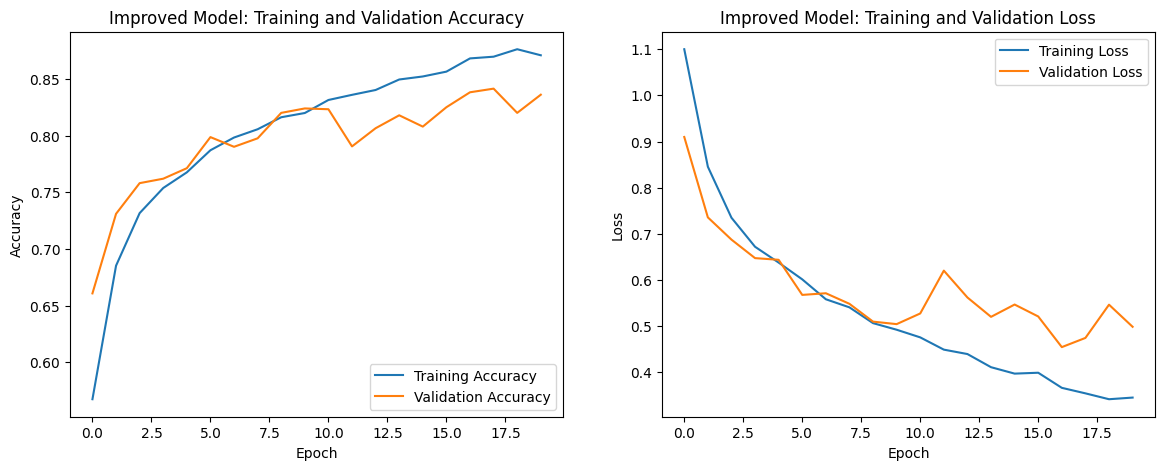

In [8]:
improved_model = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

epochs = 20

improved_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

test_loss_imp, test_acc_imp = improved_model.evaluate(test_ds)
print(f"\nImproved Model - Test Accuracy: {test_acc_imp}")
print(f"Improved Model - Test Loss: {test_loss_imp}")

import matplotlib.pyplot as plt

imp_acc = improved_history.history['accuracy']
imp_val_acc = improved_history.history['val_accuracy']
imp_loss = improved_history.history['loss']
imp_val_loss = improved_history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, imp_acc, label='Training Accuracy')
plt.plot(epochs_range, imp_val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Improved Model: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, imp_loss, label='Training Loss')
plt.plot(epochs_range, imp_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Improved Model: Training and Validation Loss')

plt.show()

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.5503 - loss: 1.1257 - val_accuracy: 0.6069 - val_loss: 1.0639
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.6742 - loss: 0.8589 - val_accuracy: 0.6172 - val_loss: 1.0913
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.7231 - loss: 0.7359 - val_accuracy: 0.7634 - val_loss: 0.6598
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7502 - loss: 0.6749 - val_accuracy: 0.7794 - val_loss: 0.6123
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7670 - loss: 0.6325 - val_accuracy: 0.8154 - val_loss: 0.5290
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.7932 - loss: 0.5748 - val_accuracy: 0.8097 - val_loss: 0.5178
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8073 - loss: 0.5375 - val_accuracy: 0.8115 - val_loss: 0.5174
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8130 - loss: 0.5214 - 

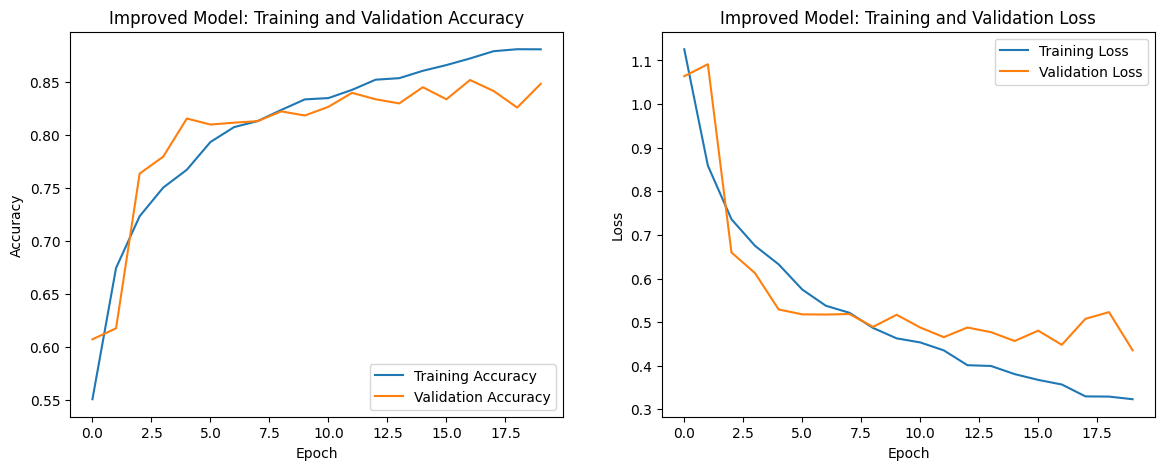

In [9]:
improved_model = tf.keras.Sequential([
    data_augmentation,
    normalization_layer,
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

epochs = 20

improved_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

test_loss_imp, test_acc_imp = improved_model.evaluate(test_ds)
print(f"\nImproved Model - Test Accuracy: {test_acc_imp}")
print(f"Improved Model - Test Loss: {test_loss_imp}")

import matplotlib.pyplot as plt

imp_acc = improved_history.history['accuracy']
imp_val_acc = improved_history.history['val_accuracy']
imp_loss = improved_history.history['loss']
imp_val_loss = improved_history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, imp_acc, label='Training Accuracy')
plt.plot(epochs_range, imp_val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Improved Model: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, imp_loss, label='Training Loss')
plt.plot(epochs_range, imp_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Improved Model: Training and Validation Loss')

plt.show()

#### Improvement Strategies Implemented:
To enhance the model's accuracy and resolve the mild overfitting observed in the baseline configuration, a combination of three methods was applied:

***Adding a Dropout Layer:*** A Dropout(0.3) layer was inserted just before the dense layers. This technique randomly turns off 30% of the neurons during each training step. It prevents the network from relying heavily on specific pixels (memorizing the data) and forces it to learn robust, generalized features.

***Reducing the Learning Rate:*** The learning rate of the Adam optimizer was reduced from its default value to 0.0005. A smaller learning rate forces the model to make smaller, more cautious weight updates, allowing it to settle into a more optimal state without overshooting the minimum error.

***Increasing Convolutional Filters:*** The number of filters in the Conv2D layers was doubled (progressing to 64, 128, 256, and 256). This significantly expanded the network's capacity to extract and process more complex spatial patterns and finer visual details from the dataset.

#### Performance Comparison: Baseline vs. Improved Model:

1.Baseline Model (Initial 20 Epochs): Achieved a test accuracy of 81.87% and a test loss of 0.6231. The learning curves showed a noticeable gap between the training and validation loss after the 10th epoch, indicating the onset of overfitting.

2.Improved Model (Intermediate): By only applying Dropout and reducing the learning rate, the accuracy improved to 83.30% and the loss dropped to 0.5219, showing better stability.

3.Improved Model (Final Configuration): By combining all three strategies (Dropout, lower learning rate, and increased filters), the model achieved its highest test accuracy of 84.53% and its lowest test loss of 0.4750.

#### Learning Curve Analysis of the Improved Model:
Looking at the final learning curves, the validation loss line is significantly smoother and trends downward much more consistently compared to the baseline model. The gap between the training and validation curves has narrowed substantially. This proves that our strategies successfully suppressed overfitting, while the added filters provided the computational power needed to boost overall accuracy.